In [6]:
from pyspark.sql import SparkSession

spark = SparkSession.builder.appName("Semana12_Supervisados").getOrCreate()

# Leemos los datos guardados en Semana 10
ruta_datos = "/home/jovyan/work/AutoTeck/datos_etiquetados_kmeans"
df_clusters = spark.read.parquet(ruta_datos)

# Renombramos 'prediction' a 'label'
df_supervisado = df_clusters.withColumnRenamed("prediction", "label")

# Train/Test split
train_data, test_data = df_supervisado.randomSplit([0.7, 0.3], seed=42)
print(f"Entrenamiento: {train_data.count()} | Prueba: {test_data.count()}")


Entrenamiento: 1849 | Prueba: 711


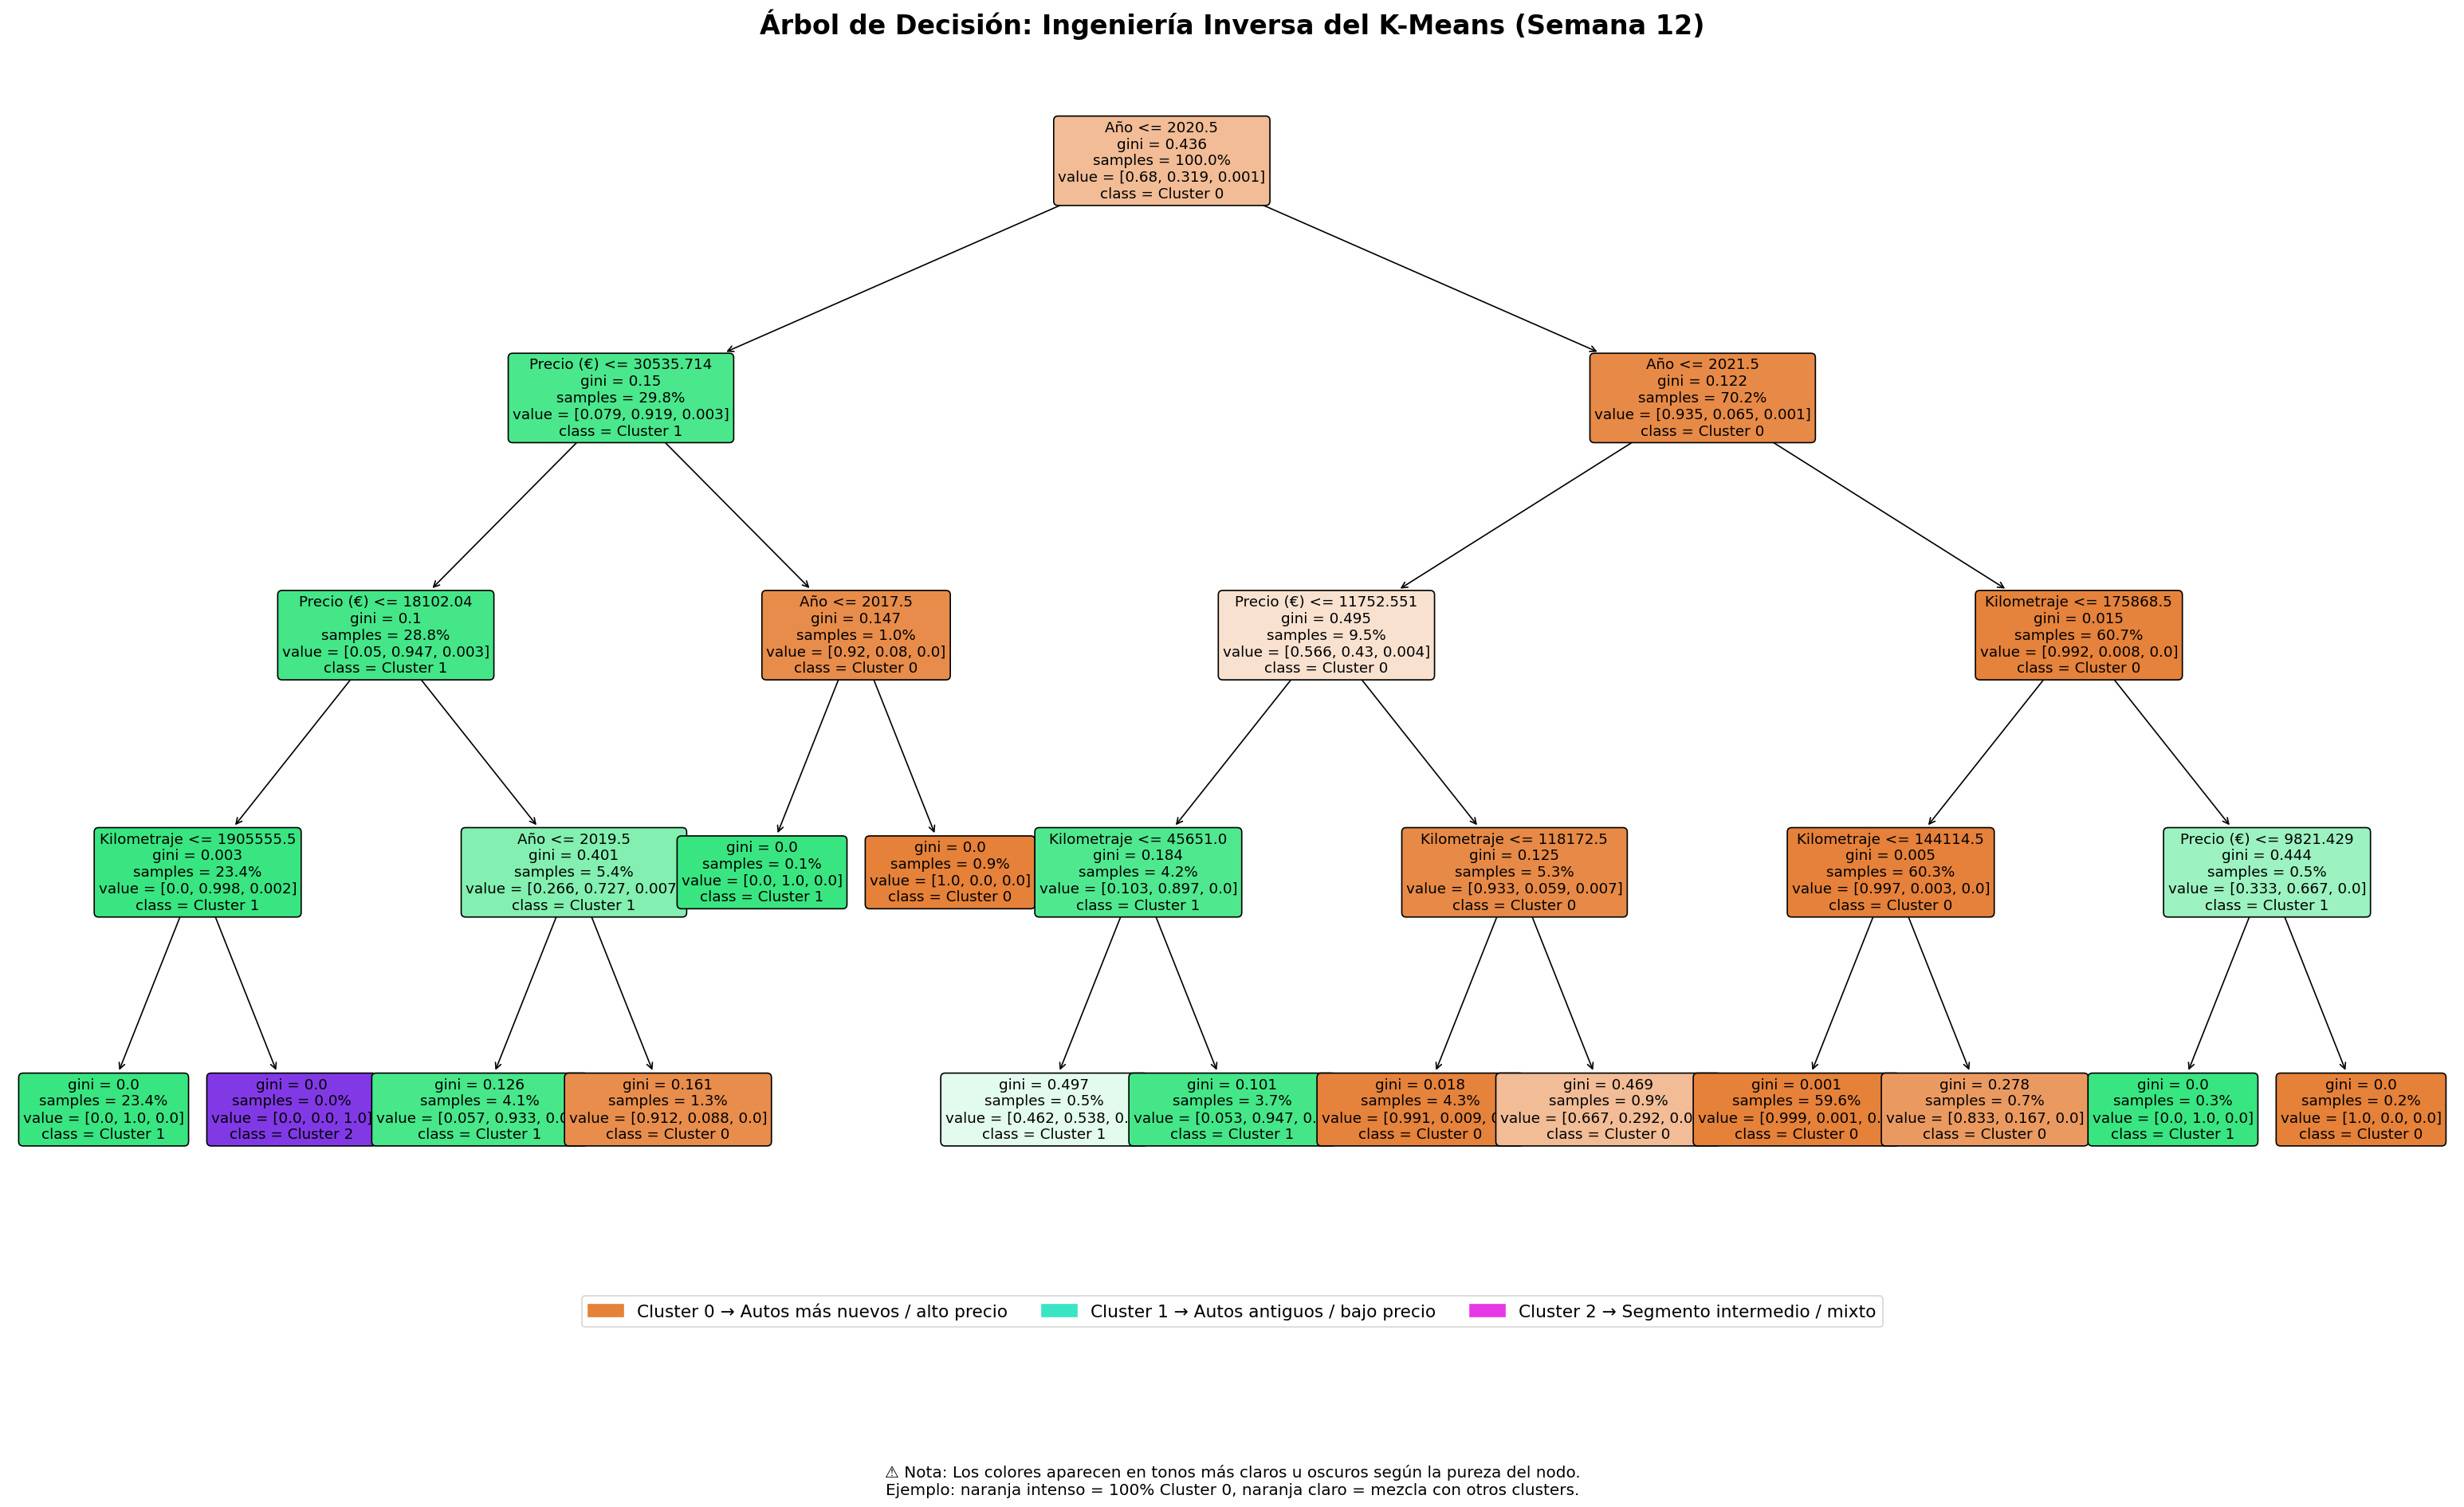

In [15]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier as SklearnClassifier
import matplotlib.patches as mpatches

# 1. Convertimos a Pandas desde Spark
df_pandas = df_supervisado.select("precio_eur", "kilometraje_num", "year_int", "label").toPandas()

# 2. Separamos características y etiqueta
X_muestra = df_pandas[["precio_eur", "kilometraje_num", "year_int"]]
y_muestra = df_pandas["label"]

# 3. Entrenamos árbol con profundidad controlada
sk_dt = SklearnClassifier(max_depth=4, random_state=42)
sk_dt.fit(X_muestra, y_muestra)

# 4. Etiquetas
nombres_features = ["Precio (€)", "Kilometraje", "Año"]
nombres_clases = [f"Cluster {int(c)}" for c in sorted(y_muestra.unique())]

# 5. Dibujamos el árbol
plt.figure(figsize=(26, 14), dpi=120)
plot_tree(
    sk_dt,
    feature_names=nombres_features,
    class_names=nombres_clases,
    filled=True,
    rounded=True,
    fontsize=11,
    proportion=True
)

plt.title("Árbol de Decisión: Ingeniería Inversa del K-Means (Semana 12)", fontsize=20, fontweight='bold')

# 6. Leyenda clara y visible
legend_patches = [
    mpatches.Patch(color="#e58139", label="Cluster 0 → Autos más nuevos / alto precio"),
    mpatches.Patch(color="#39e5c5", label="Cluster 1 → Autos antiguos / bajo precio"),
    mpatches.Patch(color="#e539e5", label="Cluster 2 → Segmento intermedio / mixto")
]
plt.legend(handles=legend_patches, loc="upper center", bbox_to_anchor=(0.5, -0.05),
           fontsize=13, frameon=True, ncol=3)

# 7. Nota explicativa sobre los tonos
plt.figtext(0.5, -0.12,
            "⚠️ Nota: Los colores aparecen en tonos más claros u oscuros según la pureza del nodo.\n"
            "Ejemplo: naranja intenso = 100% Cluster 0, naranja claro = mezcla con otros clusters.",
            ha="center", fontsize=12)

plt.tight_layout()
plt.show()



Registros de Entrenamiento: 1849
Registros de Prueba: 711
 RESULTADOS DE MODELOS SUPERVISADOS (SEMANA 11.3) 
1. Random Forest Accuracy: 97.89%
2. SVM (OneVsRest) Accuracy: 97.75%
3. Regresión Logística Accuracy: 99.02%


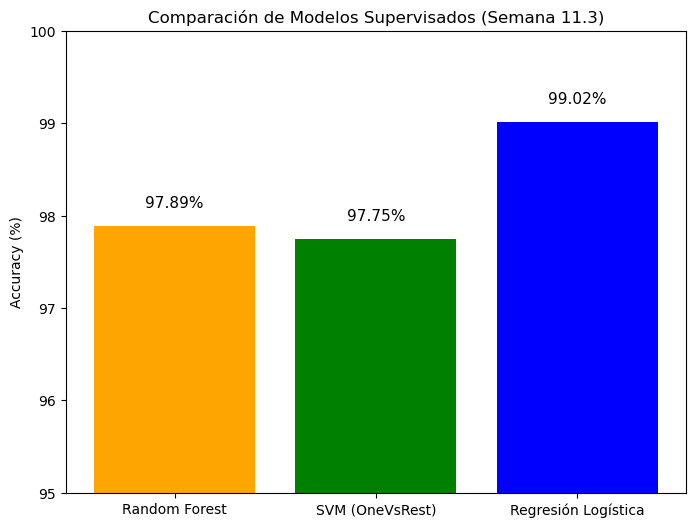

In [18]:
# ==========================================
# 11.3 Algoritmos Supervisados
# ==========================================

# 11.3.1 Preparación de los datos
# Recuperamos el DataFrame etiquetado del K-Means (Semana 10)
ruta_datos = "/home/jovyan/work/AutoTeck/datos_etiquetados_kmeans"
df_recuperado = spark.read.parquet(ruta_datos)

# Renombramos 'prediction' (del K-Means) a 'label'
df_supervisado = df_recuperado.withColumnRenamed("prediction", "label")

# Dividimos en 70% entrenamiento y 30% prueba
train_data, test_data = df_supervisado.randomSplit([0.7, 0.3], seed=42)

print(f"Registros de Entrenamiento: {train_data.count()}")
print(f"Registros de Prueba: {test_data.count()}")

# ==========================================
# 11.3.2 Entrenamiento de los 3 Modelos
# ==========================================
from pyspark.ml.classification import RandomForestClassifier, LinearSVC, LogisticRegression, OneVsRest
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Evaluador común
evaluator = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")

# MODELO 1: Random Forest
rf = RandomForestClassifier(featuresCol="scaledFeatures", labelCol="label", numTrees=20, seed=42)
rf_model = rf.fit(train_data)
rf_predictions = rf_model.transform(test_data)
accuracy_rf = evaluator.evaluate(rf_predictions)

# MODELO 2: SVM con OneVsRest
svm_binario = LinearSVC(featuresCol="scaledFeatures", labelCol="label", maxIter=10)
ovr_svm = OneVsRest(classifier=svm_binario, labelCol="label", featuresCol="scaledFeatures")
svm_model = ovr_svm.fit(train_data)
svm_predictions = svm_model.transform(test_data)
accuracy_svm = evaluator.evaluate(svm_predictions)

# MODELO 3: Regresión Logística Multinomial
lr = LogisticRegression(featuresCol="scaledFeatures", labelCol="label", maxIter=10, family="multinomial")
lr_model = lr.fit(train_data)
lr_predictions = lr_model.transform(test_data)
accuracy_lr = evaluator.evaluate(lr_predictions)

# ==========================================
# 11.3.3 Tabla Comparativa de Resultados
# ==========================================
print("==================================================")
print(" RESULTADOS DE MODELOS SUPERVISADOS (SEMANA 11.3) ")
print("==================================================")
print(f"1. Random Forest Accuracy: {accuracy_rf * 100:.2f}%")
print(f"2. SVM (OneVsRest) Accuracy: {accuracy_svm * 100:.2f}%")
print(f"3. Regresión Logística Accuracy: {accuracy_lr * 100:.2f}%")
print("==================================================")

# ==========================================
# 11.3.4 Gráfico Comparativo de Accuracies
# ==========================================
import matplotlib.pyplot as plt

# Valores obtenidos
accuracies = {
    "Random Forest": accuracy_rf * 100,
    "SVM (OneVsRest)": accuracy_svm * 100,
    "Regresión Logística": accuracy_lr * 100
}

# Gráfico de barras
plt.figure(figsize=(8,6))
plt.bar(accuracies.keys(), accuracies.values(), color=["orange","green","blue"])
plt.ylabel("Accuracy (%)")
plt.title("Comparación de Modelos Supervisados (Semana 11.3)")
plt.ylim(95, 100)  # Ajustamos el rango para ver diferencias
for i, v in enumerate(accuracies.values()):
    plt.text(i, v + 0.2, f"{v:.2f}%", ha="center", fontsize=11)
plt.show()



In [28]:
# ==========================================
# 11.4 Algoritmo Supervisado: Regresión Lineal (Autos)
# ==========================================

from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# 11.4.1 Preparar los Datos para Regresión
# Usamos variables explicativas que sí existen en la BD de autos
assembler_regresion = VectorAssembler(
    inputCols=["kilometraje_num", "year_int"],   # variables explicativas
    outputCol="features_regresion"
)
df_vector_reg = assembler_regresion.transform(df_clusters)

# Escalamos las características
scaler_reg = StandardScaler(inputCol="features_regresion", outputCol="scaledFeatures_regresion")
scaler_model_reg = scaler_reg.fit(df_vector_reg)
df_para_regresion = scaler_model_reg.transform(df_vector_reg)

# Renombramos la variable objetivo Y (precio del auto)
df_para_regresion = df_para_regresion.withColumnRenamed("precio_eur", "label_precio")
# Si tu dataset usa 'precio_num', cambia la línea anterior por:
# df_para_regresion = df_para_regresion.withColumnRenamed("precio_num", "label_precio")

# Borramos la columna prediction del K-Means
df_para_regresion = df_para_regresion.drop("prediction")

# Train/Test Split
train_reg, test_reg = df_para_regresion.randomSplit([0.7, 0.3], seed=42)

# ==========================================
# 11.4.2 Entrenar el Modelo de Regresión Lineal
# ==========================================
lr_regresion = LinearRegression(
    featuresCol="scaledFeatures_regresion",
    labelCol="label_precio",
    maxIter=10
)

lr_reg_model = lr_regresion.fit(train_reg)
predictions_regresion = lr_reg_model.transform(test_reg)

print("=== COMPARATIVA: PRECIO REAL VS PRECIO PREDICHO ===")
predictions_regresion.select("marca", "year_int", "kilometraje_num", "label_precio", "prediction").show(10)

# ==========================================
# 11.4.3 Evaluar el Modelo de Regresión
# ==========================================
evaluator_r2 = RegressionEvaluator(labelCol="label_precio", predictionCol="prediction", metricName="r2")
evaluator_rmse = RegressionEvaluator(labelCol="label_precio", predictionCol="prediction", metricName="rmse")

r2 = evaluator_r2.evaluate(predictions_regresion)
rmse = evaluator_rmse.evaluate(predictions_regresion)

print("==================================================")
print(" EVALUACIÓN DE LA REGRESIÓN (SEMANA 11.4) ")
print("==================================================")
print(f"R² (Coeficiente de Determinación): {r2 * 100:.2f}%")
print(f"RMSE (Error promedio del modelo): {rmse:.4f}")
print("==================================================")

# ==========================================
# 11.4.4 Extra: Ecuación Matemática
# ==========================================
print(f"Intercepto (Precio base): {lr_reg_model.intercept:.4f}")
for i, coef in enumerate(lr_reg_model.coefficients):
    print(f"Coeficiente {assembler_regresion.getInputCols()[i]}: {coef:.4f}")
# ==========================================
# 11.4.4 Extra: Fórmula explícita con explicación
# ==========================================
intercepto = lr_reg_model.intercept
coef_km = lr_reg_model.coefficients[0]
coef_year = lr_reg_model.coefficients[1]

print("=== Fórmula de la Regresión Lineal ===")
print(f"Precio estimado = {intercepto:.2f} "
      f"+ ({coef_km:.2f} * Kilometraje) "
      f"+ ({coef_year:.2f} * Año)\n")

print("=== Interpretación ===")
print(f"- Intercepto ≈ {intercepto:.2f} → Precio base cuando km y año son 0 (valor teórico).")
print(f"- Coef. kilometraje ≈ {coef_km:.2f} → Cada km adicional reduce el precio.")
print(f"- Coef. año ≈ {coef_year:.2f} → Cada año más nuevo aumenta el precio.")



=== COMPARATIVA: PRECIO REAL VS PRECIO PREDICHO ===
+-----+--------+---------------+------------------+------------------+
|marca|year_int|kilometraje_num|      label_precio|        prediction|
+-----+--------+---------------+------------------+------------------+
|    3|    2020|          32764|20193.877551020407|15846.193452722859|
| Audi|    2014|         115092|13214.285714285714|11102.701612279285|
| Audi|    2016|         122000|14275.510204081633|12603.119978698902|
| Audi|    2017|         107000|15816.326530612245|13396.707619598135|
| Audi|    2019|          88292| 17030.61224489796|14957.339629248017|
| Audi|    2020|          63000|19377.551020408162|15775.119915999006|
| Audi|    2018|          84917|19377.551020408162|14206.944746560883|
| Audi|    2025|           2634|21520.408163265307|19708.659055261407|
| Audi|    2022|          45000|22428.571428571428|17334.087682230398|
| Audi|    2024|          11766|23459.183673469386|18928.864889474353|
+-----+--------+---------

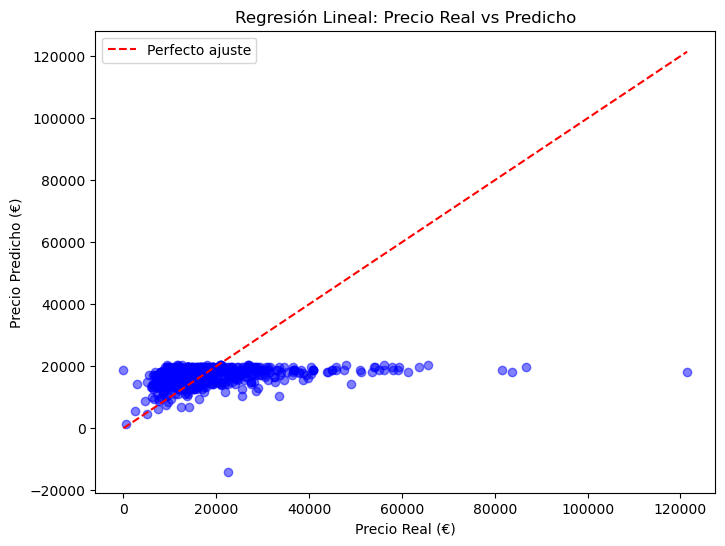

In [26]:
plt.figure(figsize=(8,6))
plt.scatter(df_pred["label_precio"], df_pred["prediction"], alpha=0.5, color="blue")
plt.plot([df_pred["label_precio"].min(), df_pred["label_precio"].max()],
         [df_pred["label_precio"].min(), df_pred["label_precio"].max()],
         color="red", linestyle="--", label="Perfecto ajuste")

plt.xlabel("Precio Real (€)")
plt.ylabel("Precio Predicho (€)")
plt.title("Regresión Lineal: Precio Real vs Predicho")
plt.legend()
plt.show()



In [32]:
# ==========================================
# 11.4.5 Ticket de Salida – Reflexión AUTOTEC
# ==========================================

print("=== Ticket de Salida – Semana 12 ===\n")

print("1. ¿El problema es el algoritmo o los datos?")
print("El bajo desempeño de la regresión lineal (R² ≈ 6%) no se debe a que el algoritmo sea incorrecto,")
print("sino a que en este ejercicio solo usamos dos variables: 'año' y 'kilometraje'.")
print("Aunque la BD de Autotec sí contiene más información relevante (marca, modelo, combustible, transmisión, etc.),")
print("el modelo se entrenó con un subset insuficiente, lo que explica el ajuste pobre.\n")

print("2. ¿Cómo lo solucionaríamos en el mundo real sin hacer trampa?")
print("La solución sería aprovechar todas las variables disponibles en la BD y, si es necesario, recolectar más datos externos.")
print("En el caso de autos, además de año y kilometraje, es clave incluir: marca, modelo, tipo de combustible, transmisión,")
print("ciudad de venta, historial de mantenciones, número de dueños y equipamiento adicional.")
print("Estos factores sí determinan el precio de un auto en el mercado real.")
print("Con más variables relevantes, el algoritmo podría construir una relación más precisa y mejorar el ajuste.")



=== Ticket de Salida – Semana 12 ===

1. ¿El problema es el algoritmo o los datos?
El bajo desempeño de la regresión lineal (R² ≈ 6%) no se debe a que el algoritmo sea incorrecto,
sino a que en este ejercicio solo usamos dos variables: 'año' y 'kilometraje'.
Aunque la BD de Autotec sí contiene más información relevante (marca, modelo, combustible, transmisión, etc.),
el modelo se entrenó con un subset insuficiente, lo que explica el ajuste pobre.

2. ¿Cómo lo solucionaríamos en el mundo real sin hacer trampa?
La solución sería aprovechar todas las variables disponibles en la BD y, si es necesario, recolectar más datos externos.
En el caso de autos, además de año y kilometraje, es clave incluir: marca, modelo, tipo de combustible, transmisión,
ciudad de venta, historial de mantenciones, número de dueños y equipamiento adicional.
Estos factores sí determinan el precio de un auto en el mercado real.
Con más variables relevantes, el algoritmo podría construir una relación más precisa y mej

In [7]:
# ==========================================
# 11.4 Algoritmo Supervisado: Regresión Lineal (Autos)
# ==========================================

from pyspark.sql import SparkSession
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

# 11.4.0 Iniciar Spark
spark = SparkSession.builder \
    .appName("Semana13_Autos_Regresion") \
    .getOrCreate()

# 11.4.1 Cargar los datos guardados del K-Means
ruta_datos = "/home/jovyan/work/AutoTeck/datos_etiquetados_kmeans"
df_clusters = spark.read.parquet(ruta_datos)

# 11.4.2 Preparar los Datos para Regresión
# Indexar la columna categórica 'marca'
index_marca = StringIndexer(inputCol="marca", outputCol="marca_index")
df_indexed = index_marca.fit(df_clusters).transform(df_clusters)

# OneHotEncoder para 'marca'
encoder = OneHotEncoder(
    inputCols=["marca_index"],
    outputCols=["marca_vec"]
)
df_encoded = encoder.fit(df_indexed).transform(df_indexed)

# VectorAssembler con las variables disponibles
assembler_regresion = VectorAssembler(
    inputCols=["kilometraje_num", "year_int", "marca_vec"],
    outputCol="features_regresion"
)
df_vector_reg = assembler_regresion.transform(df_encoded)

# Escalar las características
scaler_reg = StandardScaler(inputCol="features_regresion", outputCol="scaledFeatures_regresion")
scaler_model_reg = scaler_reg.fit(df_vector_reg)
df_para_regresion = scaler_model_reg.transform(df_vector_reg)

# Renombrar la variable objetivo (precio del auto)
df_para_regresion = df_para_regresion.withColumnRenamed("precio_eur", "label_precio")
df_para_regresion = df_para_regresion.drop("prediction")

# Train/Test Split
train_reg, test_reg = df_para_regresion.randomSplit([0.7, 0.3], seed=42)

# 11.4.3 Entrenar el Modelo de Regresión Lineal
lr_regresion = LinearRegression(
    featuresCol="scaledFeatures_regresion",
    labelCol="label_precio",
    maxIter=10
)

lr_reg_model = lr_regresion.fit(train_reg)
predictions_regresion = lr_reg_model.transform(test_reg)

print("=== COMPARATIVA: PRECIO REAL VS PRECIO PREDICHO ===")
predictions_regresion.select("marca", "year_int", "kilometraje_num", "label_precio", "prediction").show(10)

# 11.4.4 Evaluar el Modelo de Regresión
evaluator_r2 = RegressionEvaluator(labelCol="label_precio", predictionCol="prediction", metricName="r2")
evaluator_rmse = RegressionEvaluator(labelCol="label_precio", predictionCol="prediction", metricName="rmse")

r2 = evaluator_r2.evaluate(predictions_regresion)
rmse = evaluator_rmse.evaluate(predictions_regresion)

print("==================================================")
print(" EVALUACIÓN DE LA REGRESIÓN (SEMANA 11.4) ")
print("==================================================")
print(f"R² (Coeficiente de Determinación): {r2 * 100:.2f}%")
print(f"RMSE (Error promedio del modelo): {rmse:.4f}")
print("==================================================")

# 11.4.5 Extra: Ecuación Matemática
print(f"Intercepto (Precio base): {lr_reg_model.intercept:.4f}")

print("=== Coeficientes de la Regresión Lineal ===")
for i, coef in enumerate(lr_reg_model.coefficients):
    print(f"Coeficiente {i}: {coef:.4f}")

# Fórmula simplificada con interpretación
coef_km = lr_reg_model.coefficients[0]
coef_year = lr_reg_model.coefficients[1]

print("=== Fórmula simplificada ===")
print(f"Precio estimado = {lr_reg_model.intercept:.2f} "
      f"+ ({coef_km:.2f} * Kilometraje) "
      f"+ ({coef_year:.2f} * Año) "
      f"+ (Coeficientes adicionales de marca)\n")

print("=== Interpretación ===")
print(f"- Intercepto ≈ {lr_reg_model.intercept:.2f} → Precio base teórico.")
print(f"- Coef. kilometraje ≈ {coef_km:.2f} → Cada km adicional reduce el precio.")
print(f"- Coef. año ≈ {coef_year:.2f} → Cada año más nuevo aumenta el precio.")
print("- Los coeficientes adicionales corresponden a las distintas marcas codificadas.")


=== COMPARATIVA: PRECIO REAL VS PRECIO PREDICHO ===
+-----+--------+---------------+------------------+------------------+
|marca|year_int|kilometraje_num|      label_precio|        prediction|
+-----+--------+---------------+------------------+------------------+
|    3|    2020|          32764|20193.877551020407|12405.805233704858|
| Audi|    2014|         115092|13214.285714285714|24055.030649714638|
| Audi|    2016|         122000|14275.510204081633|26252.418399465736|
| Audi|    2017|         107000|15816.326530612245| 27411.60990902176|
| Audi|    2019|          88292| 17030.61224489796|29692.974433995318|
| Audi|    2020|          63000|19377.551020408162| 30885.90614383947|
| Audi|    2018|          84917|19377.551020408162|28594.021573905833|
| Audi|    2025|           2634|21520.408163265307|36633.889139438514|
| Audi|    2022|          45000|22428.571428571428|33164.949636769015|
| Audi|    2024|          11766|23459.183673469386| 35493.93465818558|
+-----+--------+---------

In [8]:
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

# ==========================================
# 11.4 Regresión Lineal
# ==========================================
lr_regresion = LinearRegression(
    featuresCol="scaledFeatures_regresion",
    labelCol="label_precio",
    maxIter=10
)

lr_reg_model = lr_regresion.fit(train_reg)
predictions_lr = lr_reg_model.transform(test_reg)

evaluator_r2 = RegressionEvaluator(labelCol="label_precio", predictionCol="prediction", metricName="r2")
evaluator_rmse = RegressionEvaluator(labelCol="label_precio", predictionCol="prediction", metricName="rmse")

r2_lr = evaluator_r2.evaluate(predictions_lr)
rmse_lr = evaluator_rmse.evaluate(predictions_lr)

print("=== Regresión Lineal ===")
print(f"R²: {r2_lr * 100:.2f}%")
print(f"RMSE: {rmse_lr:.4f}")

# ==========================================
# 13.1 Random Forest Regressor
# ==========================================
rf_regresor = RandomForestRegressor(
    featuresCol="scaledFeatures_regresion",
    labelCol="label_precio",
    numTrees=100,
    maxDepth=10,
    seed=42
)

rf_model = rf_regresor.fit(train_reg)
predictions_rf = rf_model.transform(test_reg)

r2_rf = evaluator_r2.evaluate(predictions_rf)
rmse_rf = evaluator_rmse.evaluate(predictions_rf)

print("=== Random Forest Regressor ===")
print(f"R²: {r2_rf * 100:.2f}%")
print(f"RMSE: {rmse_rf:.4f}")

# ==========================================
# Comparativa Final
# ==========================================
print("==================================================")
print(" COMPARATIVA DE MODELOS (Autos) ")
print("==================================================")
print(f"Regresión Lineal → R²: {r2_lr * 100:.2f}% | RMSE: {rmse_lr:.2f}")
print(f"Random Forest    → R²: {r2_rf * 100:.2f}% | RMSE: {rmse_rf:.2f}")
print("==================================================")


=== Regresión Lineal ===
R²: 32.26%
RMSE: 9476.5498
=== Random Forest Regressor ===
R²: 29.59%
RMSE: 9661.4809
 COMPARATIVA DE MODELOS (Autos) 
Regresión Lineal → R²: 32.26% | RMSE: 9476.55
Random Forest    → R²: 29.59% | RMSE: 9661.48
